---

# ROLLING AGGREGATIONS

---

<br><br>

>---
>**Rolling Aggregations** let you perform calculations on shifting periods of time.
>
>- This can be used to calculate things like moving averages, which are helpful in reducing noise when plotting trends

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')

In [2]:
retail = pd.read_parquet('../Data/retail_2016_2017.parquet')
retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1054944 entries, 0 to 1054943
Data columns (total 6 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   id           1054944 non-null  int64         
 1   date         1054944 non-null  datetime64[ns]
 2   store_nbr    1054944 non-null  int64         
 3   family       1054944 non-null  object        
 4   sales        1054944 non-null  float64       
 5   onpromotion  1054944 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 48.3+ MB


In [3]:
retail.head(3)

,id,date,store_nbr,family,sales,onpromotion
0,1945944,2016-01-01,1,AUTOMOTIVE,0.0,0
1,1945945,2016-01-01,1,BABY CARE,0.0,0
2,1945946,2016-01-01,1,BEAUTY,0.0,0


<br><br>

---
---



In [4]:
reduced_df = (retail
    .query("date.dt.year == 2016 and family == 'AUTOMOTIVE'")[['date', 'sales']]
    .dropna()
    .reset_index(drop=True)
    .set_index('date')
    .resample('ME').sum().astype('int') # Sum all sales by month on AUTOMOTIVE
)

reduced_df

,sales
date,
2016-01-31,12119
2016-02-29,12185
2016-03-31,12058
2016-04-30,11631
2016-05-31,11839
2016-06-30,9936
2016-07-31,11549
2016-08-31,10792
2016-09-30,9058


In [5]:
# Now we find the average of the total sales from current and past months
reduced_df = reduced_df.assign(
    last_two = reduced_df.rolling(2).mean(), # average between current & last month
    last_three = reduced_df.rolling(3).mean() # average between current & last 2 months
)

reduced_df

,sales,last_two,last_three
date,,,
2016-01-31,12119,NaN,NaN
2016-02-29,12185,12152.0,NaN
2016-03-31,12058,12121.5,12120.666667
2016-04-30,11631,11844.5,11958.000000
2016-05-31,11839,11735.0,11842.666667
2016-06-30,9936,10887.5,11135.333333
2016-07-31,11549,10742.5,11108.000000
2016-08-31,10792,11170.5,10759.000000
2016-09-30,9058,9925.0,10466.333333


<Axes: xlabel='date'>

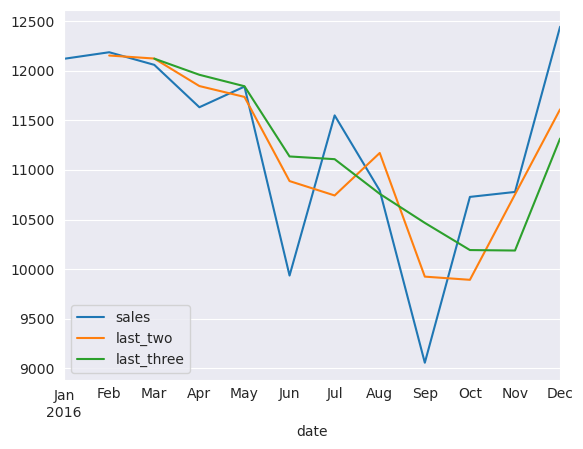

In [6]:
reduced_df.plot()

---

## LABORATORY

In [16]:
retail_lab = retail.set_index('date')[['sales']]
retail_lab = retail_lab.resample('D').sum().round(2)
retail_lab = retail_lab.query('date.dt.year == 2016')
retail_lab

,sales
date,
2016-01-01,16433.39
2016-01-02,1066677.42
2016-01-03,1226735.72
2016-01-04,955956.88
2016-01-05,835320.44
...,...
2016-12-27,842475.49
2016-12-28,951533.71
2016-12-29,894108.24


In [17]:
mean_val = retail_lab.mean()

retail_lab = retail_lab.assign(rolling_7 = retail_lab.rolling(7).mean(),
                               rolling_35 = retail_lab.rolling(35).mean(),
                               rolling_70 = retail_lab.rolling(70).mean()
)

retail_lab.round()

,sales,rolling_7,rolling_35,rolling_70
date,,,,
2016-01-01,16433.0,NaN,NaN,NaN
2016-01-02,1066677.0,NaN,NaN,NaN
2016-01-03,1226736.0,NaN,NaN,NaN
2016-01-04,955957.0,NaN,NaN,NaN
2016-01-05,835320.0,NaN,NaN,NaN
...,...,...,...,...
2016-12-27,842475.0,960198.0,906841.0,849686.0
2016-12-28,951534.0,927373.0,912494.0,854025.0
2016-12-29,894108.0,892839.0,921027.0,858469.0


<Axes: title={'center': 'Laboratory Practice - Retail Sales & Rolling Data'}, xlabel='Month', ylabel='Sales in Millions [USD]'>

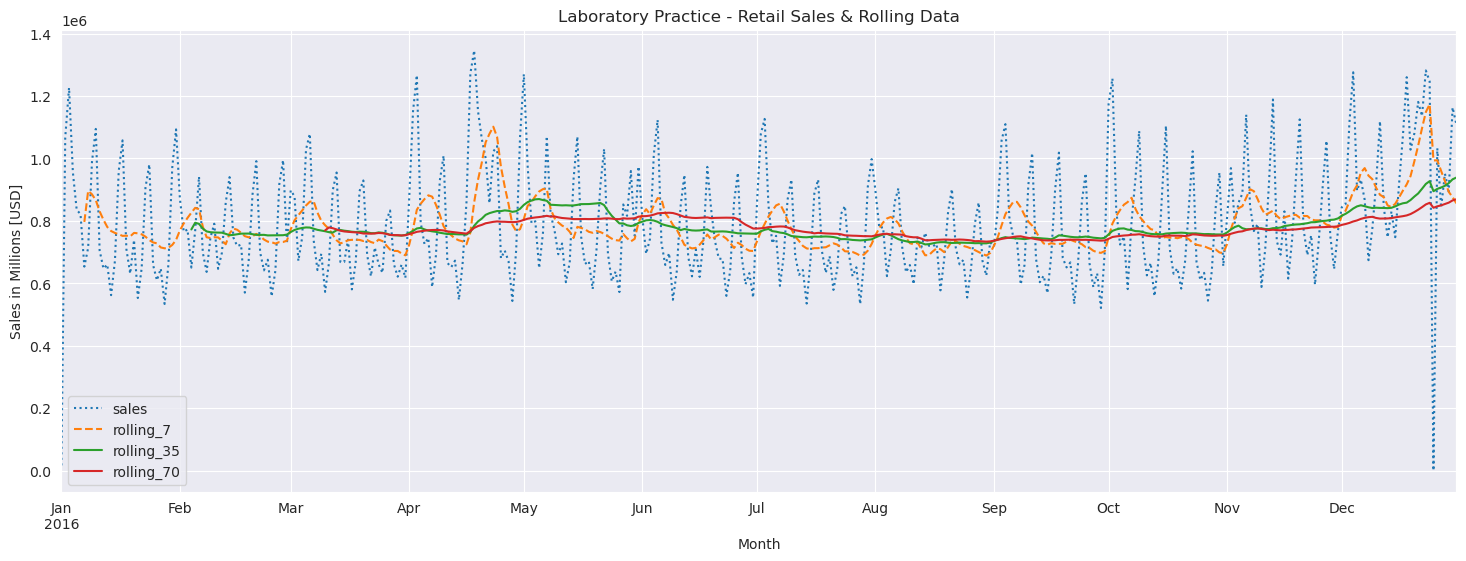

In [19]:
retail_lab.plot(figsize=(18, 6),
                title='Laboratory Practice - Retail Sales & Rolling Data',
                xlabel='Month',
                ylabel='Sales in Millions [USD]',
               style=[':', '--', '-', '-'],)